## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)

In [2]:
# Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random as rd

In [43]:
# punto 1
def simula_lanci(n):    # input numero di lanci
    lanci = np.random.randint(0, 2, size=n)    #array di 0 e 1
    return np.mean(lanci)*100   # percentuale teste

In [4]:
# punto 2
#Guardo come cambia la frequenza all'aumentare dei campioni
campioni = np.linspace(10, 20000, 100, dtype=int)   # 100 campioni tra 10 e 20000
risultati = [round(simula_lanci(n),2) for n in campioni]    # frequenze
df = pd.DataFrame({
    "Numero di lanci": campioni,
    "Percentuale di teste": risultati
})
df

,Numero di lanci,Percentuale di teste
0,10,40.00
1,211,53.08
2,413,51.33
3,615,53.82
4,817,51.04
...,...,...
95,19192,49.78
96,19394,49.75
97,19596,50.30
98,19798,50.26


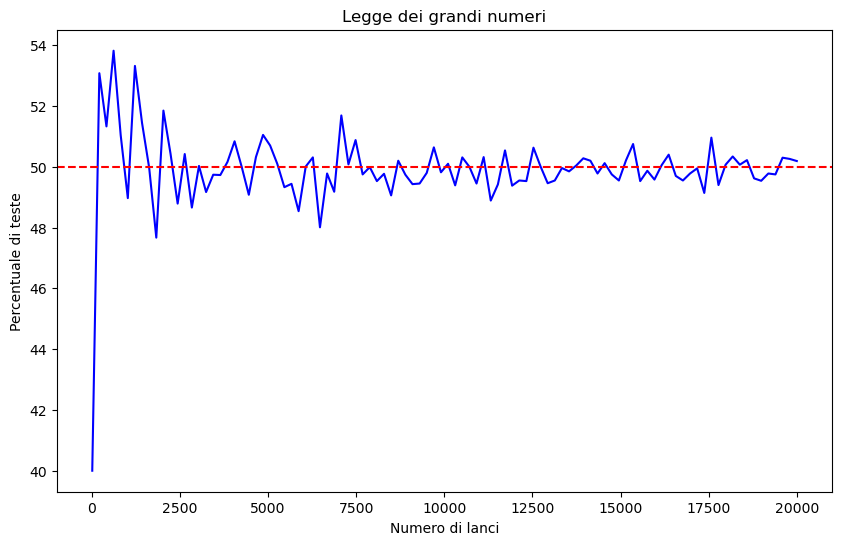

In [5]:
# Punto 3
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x="Numero di lanci", y="Percentuale di teste", color="blue")
plt.axhline(50, color='red', linestyle='--')
plt.xlabel("Numero di lanci")
plt.ylabel("Percentuale di teste")
plt.title("Legge dei grandi numeri")
plt.show()

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

In [6]:
# Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Quante righe e colonne ha il dataset?
print("Righe e colonne:", df.shape)

Righe e colonne: (891, 12)


In [ ]:
# Controlla quanti valori mancanti ci sono per colonna
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
# Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
frequente = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(frequente)
print("Valori mancanti in Embarked dopo il riempimento:", df['Embarked'].isnull().sum())

Valori mancanti in Embarked dopo il riempimento: 0


In [ ]:
#Controlla se ci sono righe duplicate
print("Righe duplicate:", df.duplicated().sum())

Righe duplicate: 0


In [ ]:
# Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
media = df['Age'].mean()
df['Age'] = df['Age'].fillna(media)
df.groupby('Pclass')['Age'].mean()

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

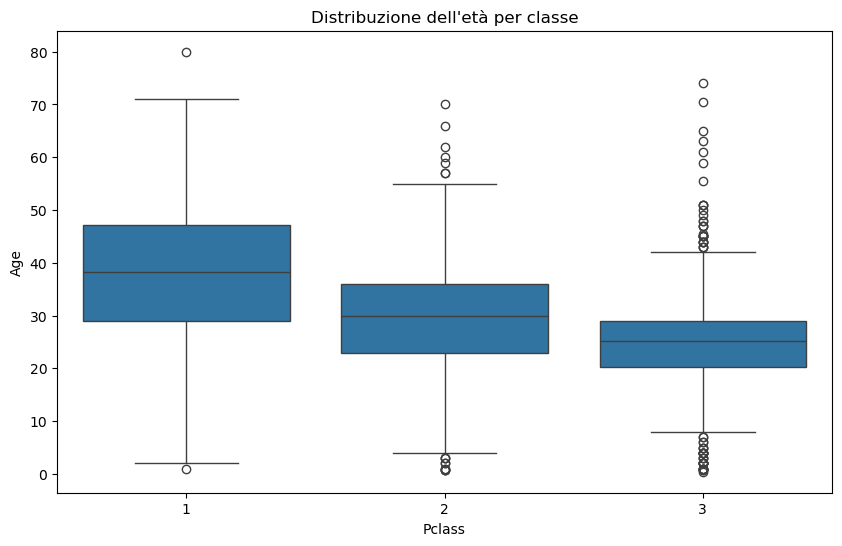

In [34]:
# Visualizza la distribuzione dell'età per classe
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Pclass', y='Age')
plt.title("Distribuzione dell'età per classe")
plt.show()

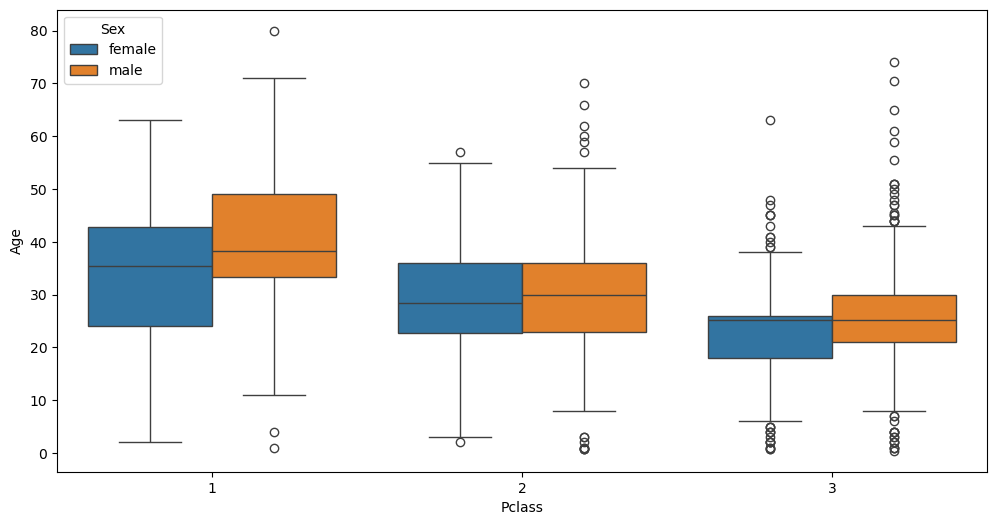

In [32]:
#Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Pclass', y='Age', hue='Sex')
plt.show()

## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [36]:
# Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
print("Conteggio per specie:")
print(df['species'].value_counts())

Conteggio per specie:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [37]:
# Calcola la lunghezza e la larghezza media dei petali per specie
print("\nMedie petali per specie:")
print(df.groupby('species')[['petal_length', 'petal_width']].mean())


Medie petali per specie:
            petal_length  petal_width
species                              
setosa             1.462        0.246
versicolor         4.260        1.326
virginica          5.552        2.026


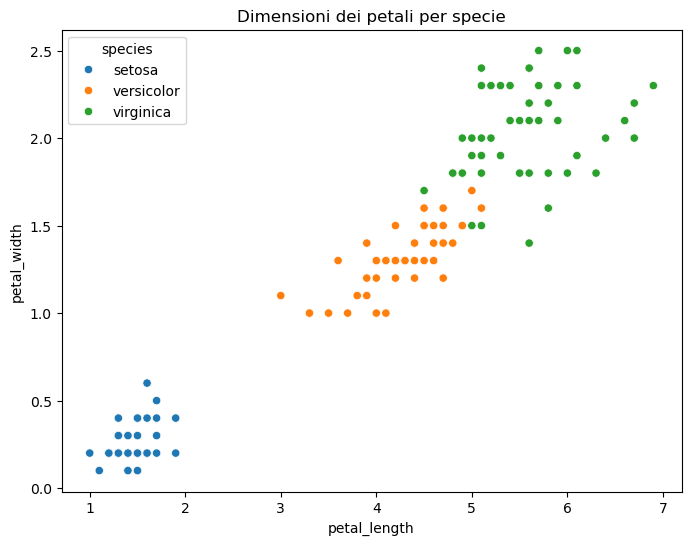

In [41]:
# Visualizza le dimensioni dei petali per specie (scatterplot)
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species')
plt.title('Dimensioni dei petali per specie')
plt.show()

In [39]:
# Crea una nuova colonna per l'area del petalo e analizzala
df['petal_area'] = df['petal_length'] * df['petal_width']
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,petal_area
0,5.1,3.5,1.4,0.2,setosa,0.28
1,4.9,3.0,1.4,0.2,setosa,0.28
2,4.7,3.2,1.3,0.2,setosa,0.26
3,4.6,3.1,1.5,0.2,setosa,0.30
4,5.0,3.6,1.4,0.2,setosa,0.28


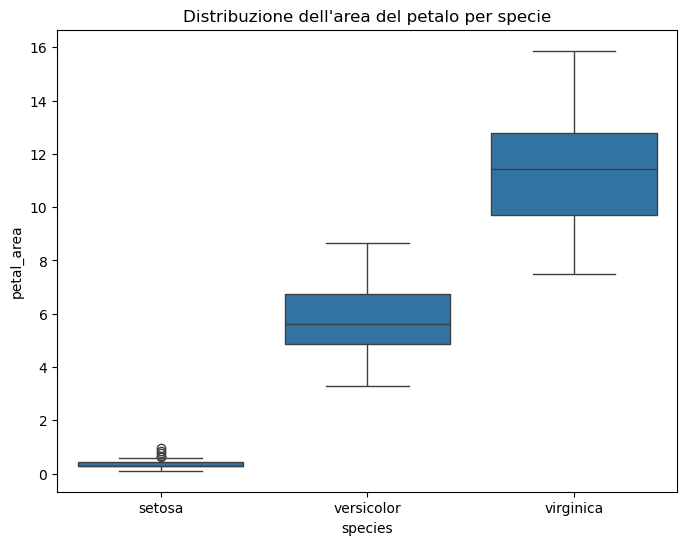

In [42]:
# Grafico della distribuzione dell'area del petalo per specie (boxplot)
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='species', y='petal_area')
plt.title("Distribuzione dell'area del petalo per specie")
plt.show()